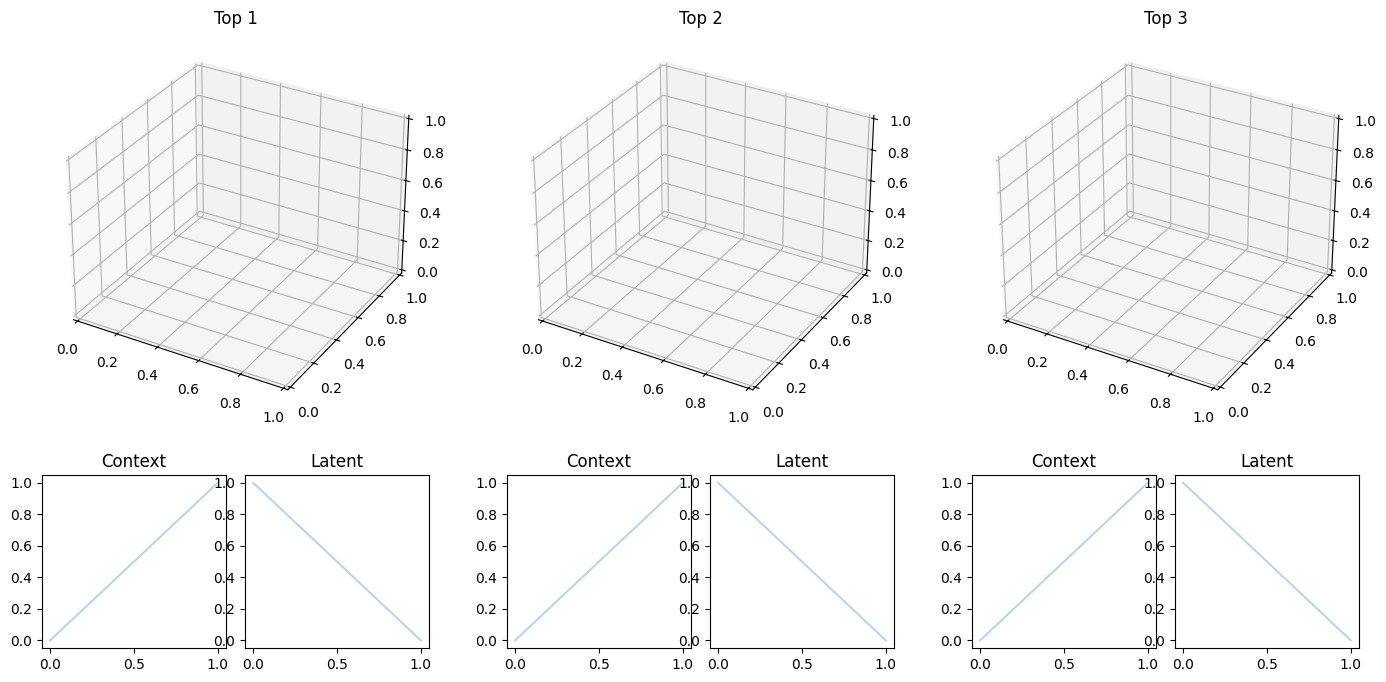

In [25]:
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch

# --- template layout ---
fig = plt.figure(figsize=(17, 8))
outer = fig.add_gridspec(2, 3, height_ratios=[2.2, 1.0], wspace=0.20, hspace=0.22)

axs3d = [fig.add_subplot(outer[0, j], projection="3d") for j in range(3)]
ctx_axes, lat_axes = [], []
for j in range(3):
    sub = outer[1, j].subgridspec(1, 2, wspace=0.10)
    ctx_axes.append(fig.add_subplot(sub[0, 0]))
    lat_axes.append(fig.add_subplot(sub[0, 1]))

# dummy content so you can see structure
for j in range(3):
    axs3d[j].set_title(f"Top {j+1}")
    ctx_axes[j].set_title("Context")
    lat_axes[j].set_title("Latent")
    ctx_axes[j].plot([0, 1], [0, 1], alpha=0.3)
    lat_axes[j].plot([0, 1], [1, 0], alpha=0.3)
# for j in range(3):
#     con = ConnectionPatch(
#         xyA=(1.00, -0.10), coordsA=ctx_axes[j].transAxes,
#         xyB=(0.00, -0.10), coordsB=lat_axes[j].transAxes,
#         arrowstyle='-|>', lw=1.4, color='0.35', mutation_scale=12
#     )
#     fig.add_artist(con)

#     p1 = fig.transFigure.inverted().transform(ctx_axes[j].transAxes.transform((1.00, -0.17)))
#     p2 = fig.transFigure.inverted().transform(lat_axes[j].transAxes.transform((0.00, -0.17)))
#     fig.text((p1[0]+p2[0])/2, p1[1], "encoder", ha="center", va="top", fontsize=9, color="0.35")


# for j in range(3):
#     pL = fig.transFigure.inverted().transform(ctx_axes[j].transAxes.transform((0.00, 1.06)))
#     pR = fig.transFigure.inverted().transform(lat_axes[j].transAxes.transform((1.00, 1.06)))
#     y = pL[1]

#     line = plt.Line2D([pL[0], pR[0]], [y, y], transform=fig.transFigure, color='0.45', lw=1.2)
#     fig.add_artist(line)
#     fig.text((pL[0]+pR[0])/2, y + 0.004, "encoder: X -> z", ha="center", va="bottom", fontsize=9, color="0.35")


# for j in range(3):
#     pA = fig.transFigure.inverted().transform(ctx_axes[j].transAxes.transform((1.01, 0.50)))
#     pB = fig.transFigure.inverted().transform(lat_axes[j].transAxes.transform((-0.01, 0.50)))
#     fig.text((pA[0]+pB[0])/2, (pA[1]+pB[1])/2, "-> encoder ->",
#              ha="center", va="center", fontsize=9, color="0.35")

# for j in range(3):
#     p1 = fig.transFigure.inverted().transform(ctx_axes[j].transAxes.transform((0.00, 1.08)))
#     p2 = fig.transFigure.inverted().transform(lat_axes[j].transAxes.transform((1.00, 1.08)))
#     fig.text((p1[0]+p2[0])/2, p1[1], "Context to Latent", ha="center", va="bottom", fontsize=10, color="0.30")


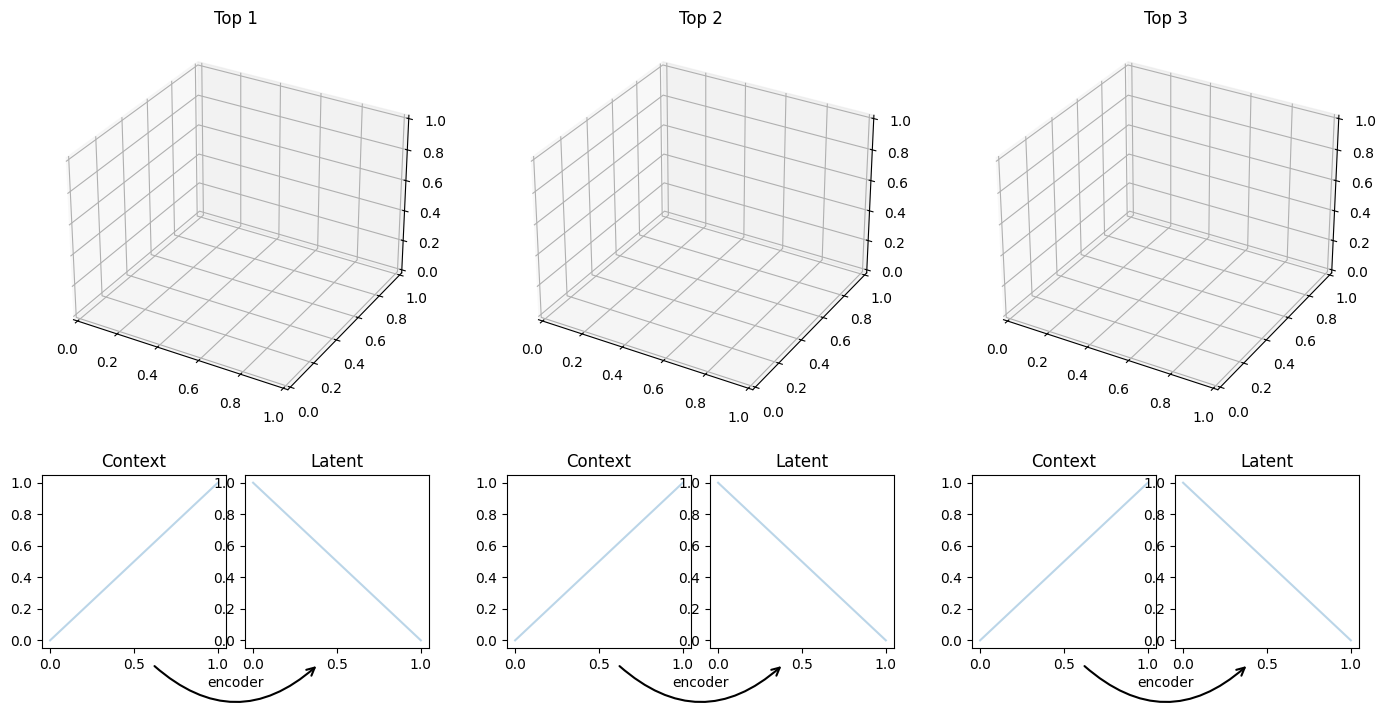

In [26]:
from matplotlib.patches import FancyArrowPatch

fig.canvas.draw()

for j in range(3):
    ax1 = ctx_axes[j]
    ax2 = lat_axes[j]

    b1 = ax1.get_position()
    b2 = ax2.get_position()

    # put both endpoints clearly below the two small axes
    y_arrow = min(b1.y0, b2.y0) - 0.02

    start = (b1.x0 + 0.60 * b1.width, y_arrow)
    end   = (b2.x0 + 0.40 * b2.width, y_arrow)

    arrow = FancyArrowPatch(
        start, end,
        transform=fig.transFigure,
        connectionstyle="arc3,rad=0.45",   # try positive first
        arrowstyle="->",
        mutation_scale=14,
        lw=1.5,
        color="black",
        clip_on=False
    )
    fig.add_artist(arrow)

    fig.text(
        (start[0] + end[0]) / 2,
        y_arrow - 0.015,
        "encoder",
        ha="center",
        va="top",
        fontsize=10
    )

fig

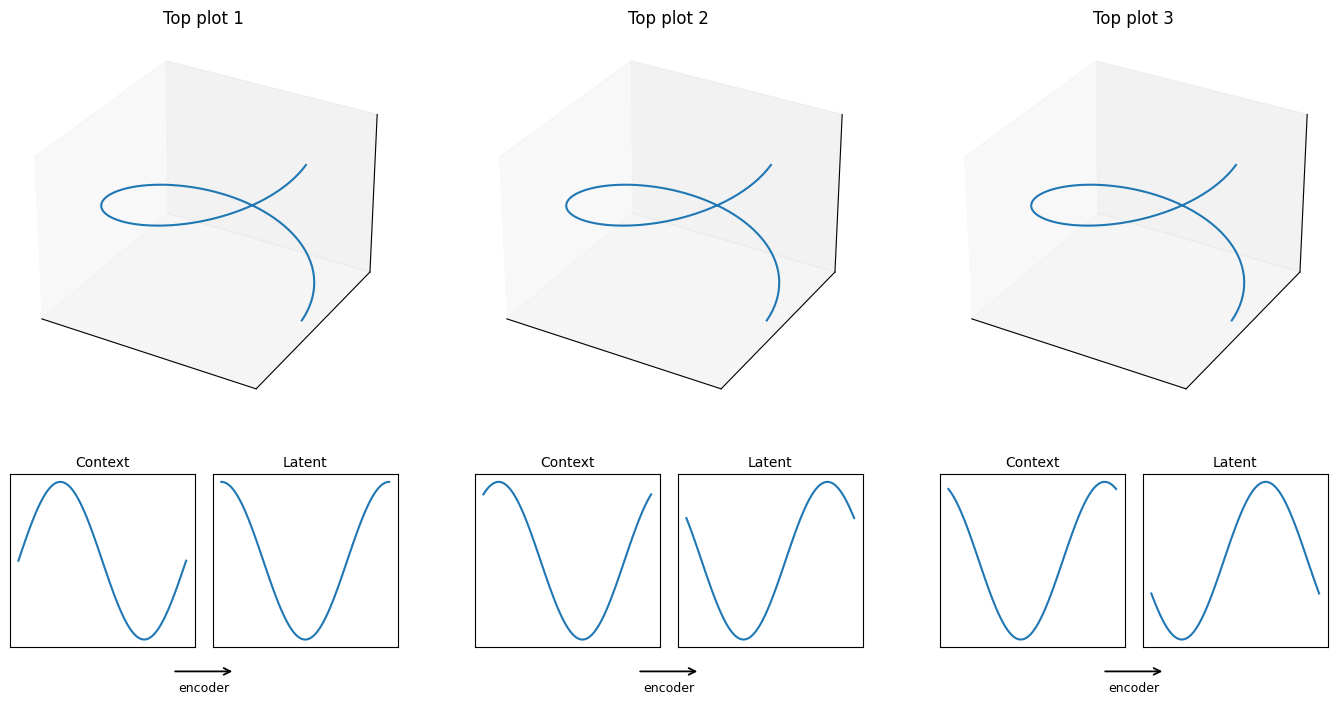

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch

# -----------------------------
# Example layout from your code
# -----------------------------
fig = plt.figure(figsize=(17, 8))
outer = fig.add_gridspec(
    2, 3,
    height_ratios=[2.2, 1.0],
    wspace=0.20,
    hspace=0.22
)

axs3d = [fig.add_subplot(outer[0, j], projection="3d") for j in range(3)]

ctx_axes, lat_axes = [], []
for j in range(3):
    sub = outer[1, j].subgridspec(1, 2, wspace=0.10)
    ctx_axes.append(fig.add_subplot(sub[0, 0]))
    lat_axes.append(fig.add_subplot(sub[0, 1]))

# -----------------------------
# Dummy content for demonstration
# -----------------------------
# top row: 3D plots
for j, ax in enumerate(axs3d):
    t = np.linspace(0, 2 * np.pi, 100)
    x = np.cos(t) + 0.2 * j
    y = np.sin(t)
    z = t
    ax.plot(x, y, z, lw=1.5)
    ax.set_title(f"Top plot {j+1}", fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

# bottom row: left/right nested plots
for j in range(3):
    x = np.linspace(0, 1, 100)

    ctx_axes[j].plot(x, np.sin(2 * np.pi * x + j), lw=1.5)
    ctx_axes[j].set_title("Context", fontsize=10)
    ctx_axes[j].set_xticks([])
    ctx_axes[j].set_yticks([])

    lat_axes[j].plot(x, np.cos(2 * np.pi * x + j), lw=1.5)
    lat_axes[j].set_title("Latent", fontsize=10)
    lat_axes[j].set_xticks([])
    lat_axes[j].set_yticks([])

# -----------------------------
# Option 3:
# vertical-down -> horizontal arrow -> vertical-up
# all drawn in figure coordinates
# -----------------------------
fig.canvas.draw()  # finalize axis positions

for j in range(3):
    b1 = ctx_axes[j].get_position()
    b2 = lat_axes[j].get_position()

    # start near the right side of left small axis
    x1 = b1.x0 + 0.88 * b1.width
    # end near the left side of right small axis
    x2 = b2.x0 + 0.12 * b2.width

    # choose a common vertical level inside each small axis
    y_in = b1.y0 + 0.45 * b1.height

    # route the connector below both axes
    y_bot = min(b1.y0, b2.y0) - 0.03

    # # left vertical segment
    # fig.add_artist(Line2D(
    #     [x1, x1], [y_in, y_bot],
    #     transform=fig.transFigure,
    #     lw=1.3,
    #     color="black"
    # ))

    # horizontal arrow segment
    fig.add_artist(FancyArrowPatch(
        (x1, y_bot), (x2, y_bot),
        transform=fig.transFigure,
        arrowstyle="->",
        mutation_scale=12,
        lw=1.3,
        color="black"
    ))

    # right vertical segment
    # fig.add_artist(Line2D(
    #     [x2, x2], [y_bot, y_in],
    #     transform=fig.transFigure,
    #     lw=1.3,
    #     color="black"
    # ))

    # optional label under the horizontal segment
    fig.text(
        (x1 + x2) / 2,
        y_bot - 0.012,
        "encoder",
        ha="center",
        va="top",
        fontsize=9
    )

plt.show()

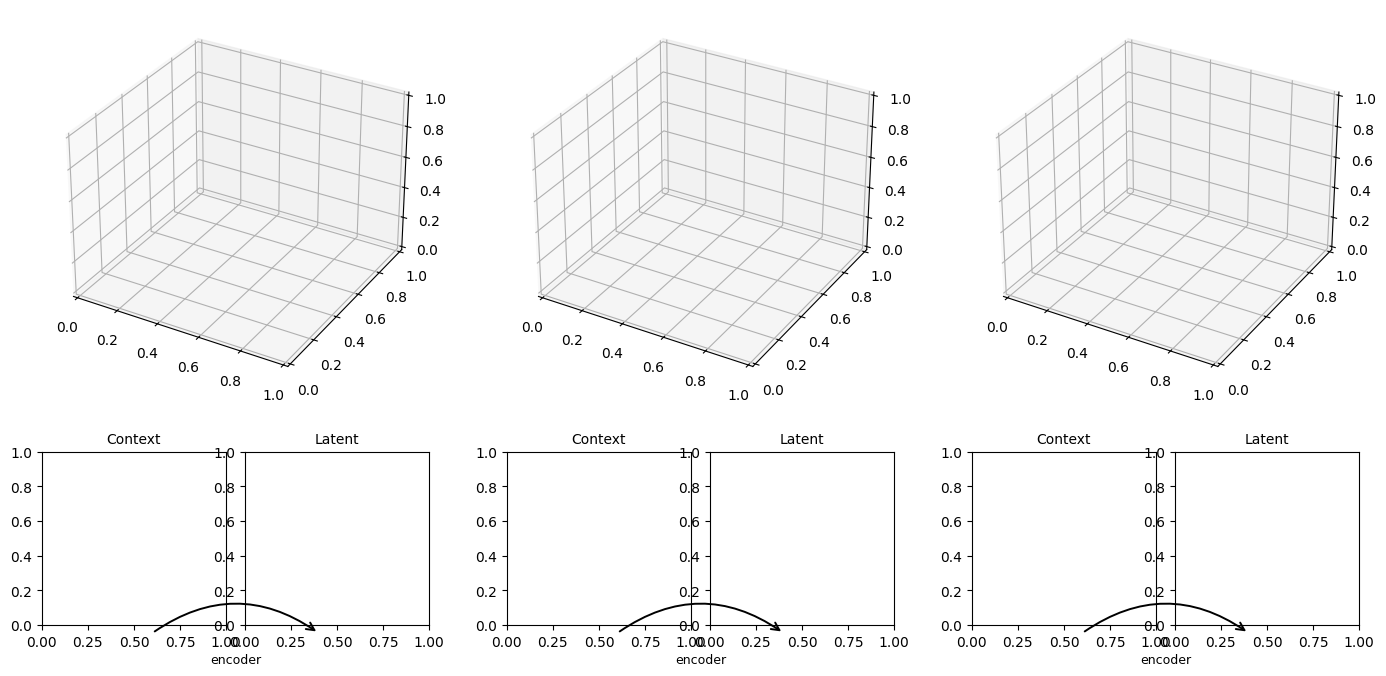

In [16]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

fig = plt.figure(figsize=(17, 8))
outer = fig.add_gridspec(2, 3, height_ratios=[2.2, 1.0], wspace=0.20, hspace=0.22)

axs3d = [fig.add_subplot(outer[0, j], projection="3d") for j in range(3)]

ctx_axes, lat_axes = [], []
for j in range(3):
    sub = outer[1, j].subgridspec(1, 2, wspace=0.10)
    ctx_axes.append(fig.add_subplot(sub[0, 0]))
    lat_axes.append(fig.add_subplot(sub[0, 1]))

# demo content
for j in range(3):
    ctx_axes[j].set_title("Context", fontsize=10)
    lat_axes[j].set_title("Latent", fontsize=10)

fig.canvas.draw()

for j in range(3):
    b1 = ctx_axes[j].get_position()
    b2 = lat_axes[j].get_position()

    start = (b1.x0 + 0.60 * b1.width, b1.y0 - 0.01)
    end   = (b2.x0 + 0.40 * b2.width, b2.y0 - 0.01)

    arrow = FancyArrowPatch(
        start, end,
        transform=fig.transFigure,
        connectionstyle="arc3,rad=-0.35",
        arrowstyle="->",
        mutation_scale=14,
        lw=1.4,
        color="black"
    )
    fig.add_artist(arrow)

    fig.text((start[0]+end[0])/2, start[1]-0.025, "encoder", ha="center", va="top", fontsize=9)

plt.show()